<a href="https://colab.research.google.com/github/vccf/Deep-Learning-Experiments/blob/YOLOv5-v1/DPFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

WHAT IS YOLOV5: A DEEP LOOK INTO THE INTERNAL
FEATURES OF THE POPULAR OBJECT DETECTOR
https://arxiv.org/pdf/2407.20892

https://github.com/ultralytics/yolov5

https://github.com/vccf/Deep-Learning-Experiments/

Improved YOLOv5: Efficient Object Detection Using Drone Images under Various Conditions
https://www.mdpi.com/2076-3417/12/14/7255

1. Goal: object detection
2. F11 4K PRO drone and VisDrone dataset
3. Comparing the original YOLOv5 model and the improved YOLOv5_Ours model
4. Indicators: precision, recall, F-1 score, and mAP
5. Improvements:
* The performance of the model that can detect object under various environmental and weather conditions, such as Clear, Cloudy, Rainy, Snowy day, Evening, Night, Low altitude, and High altitude.
* Increase of the Precision and mAP
* Reduction of the convergence speed of loss function at the training process
6. Changes:
* Precision and mAP were increased by modifying the Conv layer, the main layer of the Original YOLOv5 model.
* We replaced the SiLU activation function of the Conv layer with the ELU activation function.
* We applied the replaced ConvELU layer to the original C3, SPPF, and Conv layer of the Backbone and head part
* We used CIoU in two models: Original YOLOv5 and YOLOv5_Ours to find association with ELU activation function.
7. But there was no official github


I gonna use YOLOv5 and TPH-YOLOv5 to try to replicate and experiment on. The Dataset used will be VisDrone2019. In TPH-YOLOv5 article VisDrone2021 was used, but the article itself says it's the same dataset as VisDrone 2019. The goal of this notebook is to replicate the TPH-YOLOv5 article (within my limitations) and analyse it considering interpretability and robustness.

* https://github.com/ultralytics/yolov5
* https://github.com/cv516Buaa/tph-yolov5


* https://docs.ultralytics.com/yolov5/tutorials/train_custom_data
* https://docs.ultralytics.com/models/yolov5


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

True
Tesla T4


In [ ]:
!pip install grad-cam #for interpretability

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 59.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=4752384a953ddba569217d8ed612d7e56251ab1f3707d22e86462de17beccdfb
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


* https://github.com/jacobgil/pytorch-grad-cam
* https://jacobgil.github.io/pytorch-gradcam-book/EigenCAM%20for%20YOLO5.html

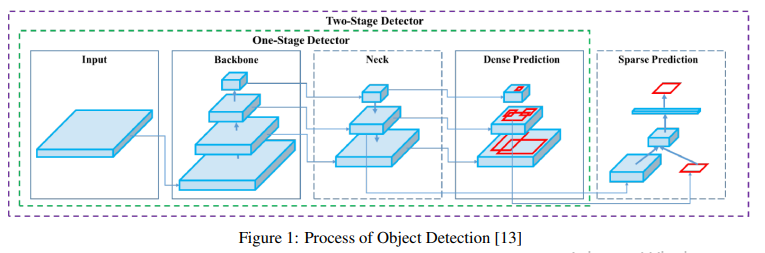

In [ ]:
!git clone https://github.com/ultralytics/yolov5.git

Cloning into 'yolov5'...
remote: Enumerating objects: 18359, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 18359 (delta 33), reused 16 (delta 16), pack-reused 18307 (from 2)
Receiving objects: 100% (18359/18359), 17.46 MiB | 18.53 MiB/s, done.
Resolving deltas: 100% (12478/12478), done.


In [ ]:
%cd yolov5

!pip install -r requirements.txt

/content/yolov5
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 16.0 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


* According to the tph-yolov article: "We find that the results of YOLOv5x are much better than YOLOv5s, YOLOv5m and YOLOv5l."
* yolov5l and yolov5x are for large architectures
* when I use --weights yolov5x.pt, it takes the pre-trained yolov5 model on COCO dataset and it adapts to VisDrone2019 dataset.


In [ ]:
!python detect.py --weights yolov5l.pt --source data/images

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
detect: weights=['yolov5l.pt'], source=data/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-503-gb8493964 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

100% 89.3M/89.3M [00:00<00:00, 98.3MB/s]

Fusing layers... 
YOLOv5l summary: 367 layers, 46533693 parameters, 0 gradient

In [ ]:
!ls

benchmarks.py	 detect.py   __pycache__       runs	       utils
CITATION.cff	 export.py   pyproject.toml    segment	       val.py
classify	 hubconf.py  README.md	       tests	       yolov5x.pt
CONTRIBUTING.md  LICENSE     README.zh-CN.md   train.py
data		 models      requirements.txt  tutorial.ipynb


In [ ]:
!pwd

/content/yolov5


In [ ]:
%cd ..

/content


In [ ]:
%mkdir datasets

In [ ]:
%cd datasets/

/content/datasets


In [ ]:
%mkdir VisDrone

In [ ]:
%cd VisDrone/

/content/datasets/VisDrone


In [ ]:
!wget https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-train.zip
!wget https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-val.zip
!wget https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-test-dev.zip
!wget https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-test-challenge.zip

--2026-06-15 00:50:42--  https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-train.zip
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/521807533/9137a849-834e-4c54-b2d5-14d12384f10f?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-06-15T01%3A31%3A31Z&rscd=attachment%3B+filename%3DVisDrone2019-DET-train.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-06-15T00%3A30%3A32Z&ske=2026-06-15T01%3A31%3A31Z&sks=b&skv=2018-11-09&sig=IDo4R905kzFXgbsWb6jLOlSW5A2%2FAXT%2B3Z9mnZoFzUk%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4MTQ4ODI0MiwibmJmIjoxNzgxNDg0NjQyLCJwYXRoIjoicmVsZWFzZ

In [ ]:
!unzip VisDrone2019-DET-train.zip
!unzip VisDrone2019-DET-val.zip
!unzip VisDrone2019-DET-test-dev.zip
!unzip VisDrone2019-DET-test-challenge.zip

A saída de streaming foi truncada nas últimas 5000 linhas.
  inflating: VisDrone2019-DET-val/images/0000291_03801_d_0000887.jpg  
  inflating: VisDrone2019-DET-val/images/0000291_04001_d_0000888.jpg  
  inflating: VisDrone2019-DET-val/images/0000291_04201_d_0000889.jpg  
  inflating: VisDrone2019-DET-val/images/0000291_04401_d_0000890.jpg  
  inflating: VisDrone2019-DET-val/images/0000291_05001_d_0000892.jpg  
  inflating: VisDrone2019-DET-val/images/0000291_05201_d_0000893.jpg  
  inflating: VisDrone2019-DET-val/images/0000293_03601_d_0000940.jpg  
  inflating: VisDrone2019-DET-val/images/0000295_00000_d_0000021.jpg  
  inflating: VisDrone2019-DET-val/images/0000295_00200_d_0000022.jpg  
  inflating: VisDrone2019-DET-val/images/0000295_00600_d_0000024.jpg  
  inflating: VisDrone2019-DET-val/images/0000295_00800_d_0000025.jpg  
  inflating: VisDrone2019-DET-val/images/0000295_01000_d_0000026.jpg  
  inflating: VisDrone2019-DET-val/images/0000295_01200_d_0000027.jpg  
  inflating: VisDr

In [ ]:
!ls

VisDrone2019-DET-test-challenge      VisDrone2019-DET-train
VisDrone2019-DET-test-challenge.zip  VisDrone2019-DET-train.zip
VisDrone2019-DET-test-dev	     VisDrone2019-DET-val
VisDrone2019-DET-test-dev.zip	     VisDrone2019-DET-val.zip


In [ ]:
%cd /content/datasets/VisDrone/VisDrone2019-DET-train

/content/datasets/VisDrone/VisDrone2019-DET-train


In [ ]:
!ls

annotations  images


In [ ]:
%cd /content/datasets/VisDrone/VisDrone2019-DET-val

/content/datasets/VisDrone/VisDrone2019-DET-val


In [ ]:
!ls

annotations  images


In [ ]:
%cd /content/datasets/VisDrone/VisDrone2019-DET-test-dev/

/content/datasets/VisDrone/VisDrone2019-DET-test-dev


In [ ]:
!ls

annotations  images


In [ ]:
%cd /content/datasets/VisDrone

/content/datasets/VisDrone


In [ ]:
%mkdir -p /content/datasets/VisDrone/images/train
%mkdir -p /content/datasets/VisDrone/images/val
%mkdir -p /content/datasets/VisDrone/labels/train
%mkdir -p /content/datasets/VisDrone/labels/val
%mkdir -p /content/datasets/VisDrone/images/test
%mkdir -p /content/datasets/VisDrone/labels/test

In [ ]:
%cp /content/datasets/VisDrone/VisDrone2019-DET-train/images/* \
   /content/datasets/VisDrone/images/train/

%cp /content/datasets/VisDrone/VisDrone2019-DET-val/images/* \
   /content/datasets/VisDrone/images/val/

%cp /content/datasets/VisDrone/VisDrone2019-DET-test-dev/images/* \
   /content/datasets/VisDrone/images/test/

In [ ]:
%%writefile /content/yolov5/data/visdrone.yaml

path: /content/datasets/VisDrone

train: images/train
val: images/val
test : images/test

nc: 10

names:
  [
    0: pedestrian,
    1: people,
    2: bicycle,
    3: car,
    4: van,
    5: truck,
    6: tricycle,
    7: awning-tricycle,
    8: bus,
    9: motor
  ]

Writing /content/yolov5/data/visdrone.yaml


In [ ]:
!ls /content/yolov5/data/

Argoverse.yaml	      hyps		 images		  VisDrone.yaml
coco128-seg.yaml      ImageNet1000.yaml  Objects365.yaml  VOC.yaml
coco128.yaml	      ImageNet100.yaml	 scripts	  xView.yaml
coco.yaml	      ImageNet10.yaml	 SKU-110K.yaml
GlobalWheat2020.yaml  ImageNet.yaml	 visdrone.yaml


In [ ]:
!cat /content/yolov5/data/visdrone.yaml


path: /content/datasets/VisDrone

train: images/train
val: images/val
test : images/test

nc: 10

names:
  [
    0: pedestrian,
    1: people,
    2: bicycle,
    3: car,
    4: van,
    5: truck,
    6: tricycle,
    7: awning-tricycle,
    8: bus,
    9: motor
  ]


In [ ]:
import os
import cv2

def convert_visdrone(ann_dir, img_dir, save_dir):
    os.makedirs(save_dir, exist_ok=True)

    files = [f for f in os.listdir(ann_dir) if f.endswith(".txt")]

    for ann_file in files:

        img_file = ann_file.replace(".txt", ".jpg")
        img_path = os.path.join(img_dir, img_file)

        img = cv2.imread(img_path)
        if img is None:
            continue

        h, w = img.shape[:2]

        yolo_lines = []

        with open(os.path.join(ann_dir, ann_file)) as f:
            for line in f:

                parts = line.strip().split(",")

                if len(parts) < 8:
                    continue

                x = float(parts[0])
                y = float(parts[1])
                bw = float(parts[2])
                bh = float(parts[3])
                cls = int(parts[5])

                # ignore ignored regions
                if cls == 0:
                    continue

                xc = (x + bw/2) / w
                yc = (y + bh/2) / h

                bw /= w
                bh /= h

                yolo_cls = cls - 1

                yolo_lines.append(
                    f"{yolo_cls} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}"
                )

        with open(os.path.join(save_dir, ann_file), "w") as out:
            out.write("\n".join(yolo_lines))

In [ ]:
convert_visdrone(
    "/content/datasets/VisDrone/VisDrone2019-DET-train/annotations",
    "/content/datasets/VisDrone/VisDrone2019-DET-train/images",
    "/content/datasets/VisDrone/labels/train"
)

convert_visdrone(
    "/content/datasets/VisDrone/VisDrone2019-DET-val/annotations",
    "/content/datasets/VisDrone/VisDrone2019-DET-val/images",
    "/content/datasets/VisDrone/labels/val"
)

convert_visdrone(
    "/content/datasets/VisDrone/VisDrone2019-DET-test-dev/annotations",
    "/content/datasets/VisDrone/VisDrone2019-DET-test-dev/images",
    "/content/datasets/VisDrone/labels/test-dev"
)

In [ ]:
!head -5 /content/datasets/VisDrone/labels/train/9999999_00879_d_0000403.txt

3 0.356000 0.907667 0.059000 0.174000
0 0.368750 0.774333 0.016500 0.038000
0 0.385500 0.638667 0.013000 0.034667
3 0.363500 0.609000 0.035000 0.083333
3 0.366000 0.533000 0.031000 0.074000


In [ ]:
!find /content/datasets/VisDrone -name "*.cache" -delete

In [ ]:
!find /content/datasets/VisDrone/images/train -name "*.jpg" | wc -l
!find /content/datasets/VisDrone/labels/train -name "*.txt" | wc -l

6471
6471


In [ ]:
!pwd

/content/datasets/VisDrone


In [ ]:
!ls /content/datasets/VisDrone/labels/train | head

0000002_00005_d_0000014.txt
0000002_00448_d_0000015.txt
0000003_00231_d_0000016.txt
0000007_04999_d_0000036.txt
0000007_05499_d_0000037.txt
0000007_05999_d_0000038.txt
0000008_00889_d_0000039.txt
0000008_01999_d_0000040.txt
0000008_02499_d_0000041.txt
0000008_02999_d_0000042.txt


In [ ]:
!find /content/datasets/VisDrone/images/train -name "*.jpg" | wc -l
!find /content/datasets/VisDrone/labels/train -name "*.txt" | wc -l

!find /content/datasets/VisDrone/images/val -name "*.jpg" | wc -l
!find /content/datasets/VisDrone/labels/val -name "*.txt" | wc -l

6471
6471
548
548


In [ ]:
!grep -R "," /content/datasets/VisDrone/labels/train | head
!grep -R "," /content/datasets/VisDrone/labels/val | head

In [ ]:
!pwd

/content/datasets/VisDrone


In [ ]:
%cd ..

/content/datasets


In [ ]:
%cd ..

/content


In [ ]:
%cd yolov5

/content/yolov5


In [ ]:
!grep -R "^10 " /content/datasets/VisDrone/labels/train | head

/content/datasets/VisDrone/labels/train/9999965_00000_d_0000029.txt:10 0.517500 0.032995 0.022143 0.065990
/content/datasets/VisDrone/labels/train/9999965_00000_d_0000029.txt:10 0.447857 0.027919 0.021429 0.055838
/content/datasets/VisDrone/labels/train/9999955_00000_d_0000269.txt:10 0.637857 0.649112 0.004286 0.019036
/content/datasets/VisDrone/labels/train/9999955_00000_d_0000269.txt:10 0.261071 0.673223 0.013571 0.029188
/content/datasets/VisDrone/labels/train/9999981_00000_d_0000156.txt:10 0.265000 0.365714 0.024286 0.062857
/content/datasets/VisDrone/labels/train/0000072_00000_d_0000001.txt:10 0.854779 0.235294 0.022794 0.026144
/content/datasets/VisDrone/labels/train/0000072_00000_d_0000001.txt:10 0.913971 0.152288 0.016176 0.027451
/content/datasets/VisDrone/labels/train/0000279_02601_d_0000597.txt:10 0.598162 0.145098 0.009559 0.018301
/content/datasets/VisDrone/labels/train/9999937_00000_d_0000074.txt:10 0.710856 0.087199 0.054280 0.048237
/content/datasets/VisDrone/labels/tra

In [ ]:
!awk '{print $1}' /content/datasets/VisDrone/labels/train/*.txt | sort -n | tail

10
10
10
10
10
10
10
10
10
10


In [ ]:
from pathlib import Path

for folder in [
    "/content/datasets/VisDrone/labels/train",
    "/content/datasets/VisDrone/labels/val"
]:
    for f in Path(folder).glob("*.txt"):
        with open(f) as infile:
            lines = infile.readlines()

        lines = [line for line in lines if not line.startswith("10 ")]

        with open(f, "w") as outfile:
            outfile.writelines(lines)

print("Done")

Done


In [ ]:
!awk '{print $1}' /content/datasets/VisDrone/labels/train/*.txt | sort -n | tail

9
9
9
9
9
9
9
9
9
9


In [ ]:
!find /content/datasets/VisDrone -name "*.cache" -delete

In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

True
Tesla T4


In [ ]:
#!python train.py \
#  --weights yolov5x.pt \
#  --data /content/yolov5/data/visdrone.yaml \
#  --img 640 \
#  --batch 2 \
#  --epochs 1 \
#  --workers 0

This way just to test, now we gonna properly train it.

* https://docs.ultralytics.com/guides/model-training-tips
* pretrained=True will use default pretrained weights, or you can specify a path to a custom pretrained model
* Ideally to train I'd use 300 epochs, but due to memory constraints, that won't be possible.
* patience=5 means training will stop if there's no improvement in validation metrics for 5 consecutive epochs
* optimizers options are:
* * SGD (Stochastic Gradient Descent)
* * Adam (Adaptive Moment Estimation)
* * RMSProp (Root Mean Square Propagation)
* * MuSGD (Muon + SGD hybrid)
* I chose optimizer=auto, for automatic selection based on model configuration.




In [ ]:
!python train.py \
  --weights yolov5l.pt \
  --optimizer=Adam \
  --img 1280 \
  --batch 2 \
  --epochs 8 \
  --cache \
  --patience=5 \
  --hyp data/hyps/hyp.scratch-high.yaml \
  --data /content/yolov5/data/visdrone.yaml #VisDrone.yaml is the og

A saída de streaming foi truncada nas últimas 5000 linhas.
        7/7      5.59G    0.05297      0.173    0.01762        284       1280:  23% 748/3236 [04:37<16:12,  2.56it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
        7/7      5.59G    0.05295     0.1731    0.01762        230       1280:  23% 749/3236 [04:37<16:08,  2.57it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
        7/7      5.59G    0.05293      0.173    0.01762         59       1280:  23% 750/3236 [04:38<16:10,  2.56it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
        7/7      5.5

In [ ]:
#%cd /content/yolov5

#!python val.py \
#  --weights yolov5l.pt \
#  --data /content/yolov5/data/visdrone.yaml \
#  --img 640

In [ ]:
!python val.py \
    --weights runs/train/exp2/weights/best.pt \
    --data /content/yolov5/data/visdrone.yaml \
    --img 1280

val: data=/content/yolov5/data/visdrone.yaml, weights=['runs/train/exp2/weights/best.pt'], batch_size=32, imgsz=1280, conf_thres=0.001, iou_thres=0.6, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v7.0-503-gb8493964 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 267 layers, 46156743 parameters, 0 gradients, 107.8 GFLOPs
val: Scanning /content/datasets/VisDrone/labels/val.cache... 548 images, 0 backgrounds, 0 corrupt: 100% 548/548 [00:00<?, ?it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% 18/18 [00:54<00:00,  3.01s/it]
                   all        548      38759      0.367       0.35      0.293      0.166
     {0: 'pedestrian'}        548       8844      0.433      0.552      0.502      0.229
       

In [ ]:
!python benchmarks.py

benchmarks: weights=/content/yolov5/yolov5s.pt, imgsz=640, batch_size=1, data=/content/yolov5/data/coco128.yaml, device=, half=False, test=False, pt_only=False, hard_fail=False
YOLOv5 🚀 v7.0-503-gb8493964 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

100% 14.1M/14.1M [00:00<00:00, 101MB/s] 

YOLOv5 🚀 v7.0-503-gb8493964 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs

Dataset not found ⚠️, missing paths ['/content/datasets/coco128/images/train2017']
######################################################################## 100.0%
Unzipping /content/datasets/coco128.zip...
Dataset download success ✅ (0.8s), saved to /content/datasets
val: Scanning /content/datasets/coco128/labels/train2017... 126 images, 2 backgrounds, 0 corrupt: 100% 128/128 [00:00<00:00, 1348.06it/s]
val: New cache created: /content/datasets/coco128/labels/train2017.cache
                 Class     

https://github.com/ultralytics/yolov5/issues/9935

The validation output will report:

* mAP@0.5
* mAP@0.5:0.95
* Precision
* Recall

See on: runs/val/exp/

├── confusion_matrix.png

├── F1_curve.png

├── PR_curve.png

├── P_curve.png

├── R_curve.png

├── confusion_matrix.png

├── PR_curve.png Precison-Recall Curve

https://github.com/hysts/pytorch_D-RISE


In [ ]:
python val.py \
    --weights runs/train/exp/weights/best.pt \
    --data /content/yolov5/data/visdrone.yaml \
    --img 960 \
    --task test \
    --verbose \
    --save-txt \
    --save-conf

In [ ]:
#Feature Visualization
#visualize intermediate activations
activation = {}

def hook_fn(module, input, output):
    activation['feat'] = output.detach()

layer = model.model[10]
hook = layer.register_forward_hook(hook_fn)

results = model(img)

features = activation['feat']

NameError: name 'model' is not defined

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(features[0,0].cpu())
plt.show()

In [ ]:
#GradCAM and EigenCAM -> interpretability methods

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam import EigenCAM #to compare with GradCAM

target_layers = [model.model.model[-2]]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

grayscale_cam = cam(input_tensor)

NameError: name 'model' is not defined

In [ ]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')
import torch
import cv2
import numpy as np
import requests
import torchvision.transforms as transforms
from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image, scale_cam_image
from PIL import Image

COLORS = np.random.uniform(0, 255, size=(80, 3))

def parse_detections(results):
    detections = results.pandas().xyxy[0]
    detections = detections.to_dict()
    boxes, colors, names = [], [], []

    for i in range(len(detections["xmin"])):
        confidence = detections["confidence"][i]
        if confidence < 0.2:
            continue
        xmin = int(detections["xmin"][i])
        ymin = int(detections["ymin"][i])
        xmax = int(detections["xmax"][i])
        ymax = int(detections["ymax"][i])
        name = detections["name"][i]
        category = int(detections["class"][i])
        color = COLORS[category]

        boxes.append((xmin, ymin, xmax, ymax))
        colors.append(color)
        names.append(name)
    return boxes, colors, names


def draw_detections(boxes, colors, names, img):
    for box, color, name in zip(boxes, colors, names):
        xmin, ymin, xmax, ymax = box
        cv2.rectangle(
            img,
            (xmin, ymin),
            (xmax, ymax),
            color,
            2)

        cv2.putText(img, name, (xmin, ymin - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2,
                    lineType=cv2.LINE_AA)
    return img


image_url = "https://upload.wikimedia.org/wikipedia/commons/f/f1/Puppies_%284984818141%29.jpg"
img = np.array(Image.open(requests.get(image_url, stream=True).raw))
img = cv2.resize(img, (640, 640))
rgb_img = img.copy()
img = np.float32(img) / 255
transform = transforms.ToTensor()
tensor = transform(img).unsqueeze(0)

model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)
model.eval()
model.cpu()
target_layers = [model.model.model.model[-2]]

results = model([rgb_img])
boxes, colors, names = parse_detections(results)
detections = draw_detections(boxes, colors, names, rgb_img.copy())
Image.fromarray(detections)

UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x7efd446d9ee0>

In [ ]:
cam = EigenCAM(model, target_layers, use_cuda=False)
grayscale_cam = cam(tensor)[0, :, :]
cam_image = show_cam_on_image(img, grayscale_cam, use_rgb=True)
Image.fromarray(cam_image)

NameError: name 'model' is not defined

In [ ]:
def renormalize_cam_in_bounding_boxes(boxes, colors, names, image_float_np, grayscale_cam):
    """Normalize the CAM to be in the range [0, 1]
    inside every bounding boxes, and zero outside of the bounding boxes. """
    renormalized_cam = np.zeros(grayscale_cam.shape, dtype=np.float32)
    for x1, y1, x2, y2 in boxes:
        renormalized_cam[y1:y2, x1:x2] = scale_cam_image(grayscale_cam[y1:y2, x1:x2].copy())
    renormalized_cam = scale_cam_image(renormalized_cam)
    eigencam_image_renormalized = show_cam_on_image(image_float_np, renormalized_cam, use_rgb=True)
    image_with_bounding_boxes = draw_detections(boxes, colors, names, eigencam_image_renormalized)
    return image_with_bounding_boxes


renormalized_cam_image = renormalize_cam_in_bounding_boxes(boxes, colors, names, img, grayscale_cam)
Image.fromarray(renormalized_cam_image)

In [ ]:
Image.fromarray(np.hstack((rgb_img, cam_image, renormalized_cam_image)))

In [ ]:
#Saliency Maps: shows which pixels most influence detections.

input_tensor.requires_grad = True

output = model(input_tensor)

score = output[...,4].max()

score.backward()

saliency = input_tensor.grad.abs()

NameError: name 'input_tensor' is not defined

In [ ]:
#Robustness Evaluation

# 1. Gaussian Noise
noisy = image + np.random.normal(0,25,image.shape)

# Measure: mAP_clean, mAP_noisy

# 2. Blur
cv2.GaussianBlur(image,(5,5),0)

# 3. Brightness
image = image * 1.3

# 4. Occlusion

image[200:400,200:400] = 0 # Hide image regions

# Compare mAP degradation.

NameError: name 'image' is not defined

In [ ]:
#Error Analysis
#Inspect: False Positives, False Negatives, Localization Errors, Class Confusions

In [ ]:
#Calibration Analysis
#Compute: Expected Calibration Error (ECE), Reliability Diagrams

from netcal.metrics import ECE

Evaluation for YOLOv5l on VisDrone:

1. mAP@0.5
2. mAP@0.5:0.95
3. Precision
4. Recall
5. F1-score
6. PR Curve
7. Confusion Matrix
8. Grad-CAM
9. Feature Maps
10. Robustness tests (noise, blur, brightness)
11. FPS / inference time
12. Error analysis examples

In [ ]:
!python detect.py --weights yolov5l.pt --source data/images/bus.jpg --visualize

detect: weights=['yolov5l.pt'], source=data/images/bus.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=True, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-503-gb8493964 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
YOLOv5l summary: 367 layers, 46533693 parameters, 0 gradients, 109.0 GFLOPs
Saving runs/detect/exp2/bus/stage0_Conv_features.png... (32/64)
Saving runs/detect/exp2/bus/stage1_Conv_features.png... (32/128)
Saving runs/detect/exp2/bus/stage2_C3_features.png... (32/128)
Saving runs/detect/exp2/bus/stage3_Conv_features.png... (32/256)
Saving runs/detect/exp2/bus/stage4_C3_features.png... (32/256)
Saving run

In [ ]:
def feature_visualization(x, module_type, stage, n=32, save_dir=Path('runs/detect/exp2')):
     """
     x:              Features to be visualized
     module_type:    Module type
     stage:          Module stage within model
     n:              Maximum number of feature maps to plot
     save_dir:       Directory to save results
     """
     if 'Detect' not in module_type:
         batch, channels, height, width = x.shape  # batch, channels, height, width
         if height > 1 and width > 1:
             f = f"stage{stage}_{module_type.split('.')[-1]}_features.png"  # filename

             blocks = torch.chunk(x[0].cpu(), channels, dim=0)  # select batch index 0, block by channels
             n = min(n, channels)  # number of plots
             fig, ax = plt.subplots(math.ceil(n / 8), 8, tight_layout=True)  # 8 rows x n/8 cols
             ax = ax.ravel()
             plt.subplots_adjust(wspace=0.05, hspace=0.05)
             for i in range(n):
                 ax[i].imshow(blocks[i].squeeze())  # cmap='gray'
                 ax[i].axis('off')

             print(f'Saving {save_dir / f}... ({n}/{channels})')
             plt.savefig(save_dir / f, dpi=300, bbox_inches='tight')
             plt.close()

In [ ]:
!ls /content/yolov5/runs/

detect	train  val


In [ ]:
!ls /content/yolov5/runs/detect/

exp  exp2


In [ ]:
!ls /content/yolov5/runs/detect/exp2

bus  bus.jpg


In [ ]:
!ls /content/yolov5/runs/val/exp3/

confusion_matrix.png  R_curve.png	     val_batch1_pred.jpg
F1_curve.png	      val_batch0_labels.jpg  val_batch2_labels.jpg
P_curve.png	      val_batch0_pred.jpg    val_batch2_pred.jpg
PR_curve.png	      val_batch1_labels.jpg


In [ ]:
!find runs/val -name "confusion_matrix.png"

runs/val/exp3/confusion_matrix.png


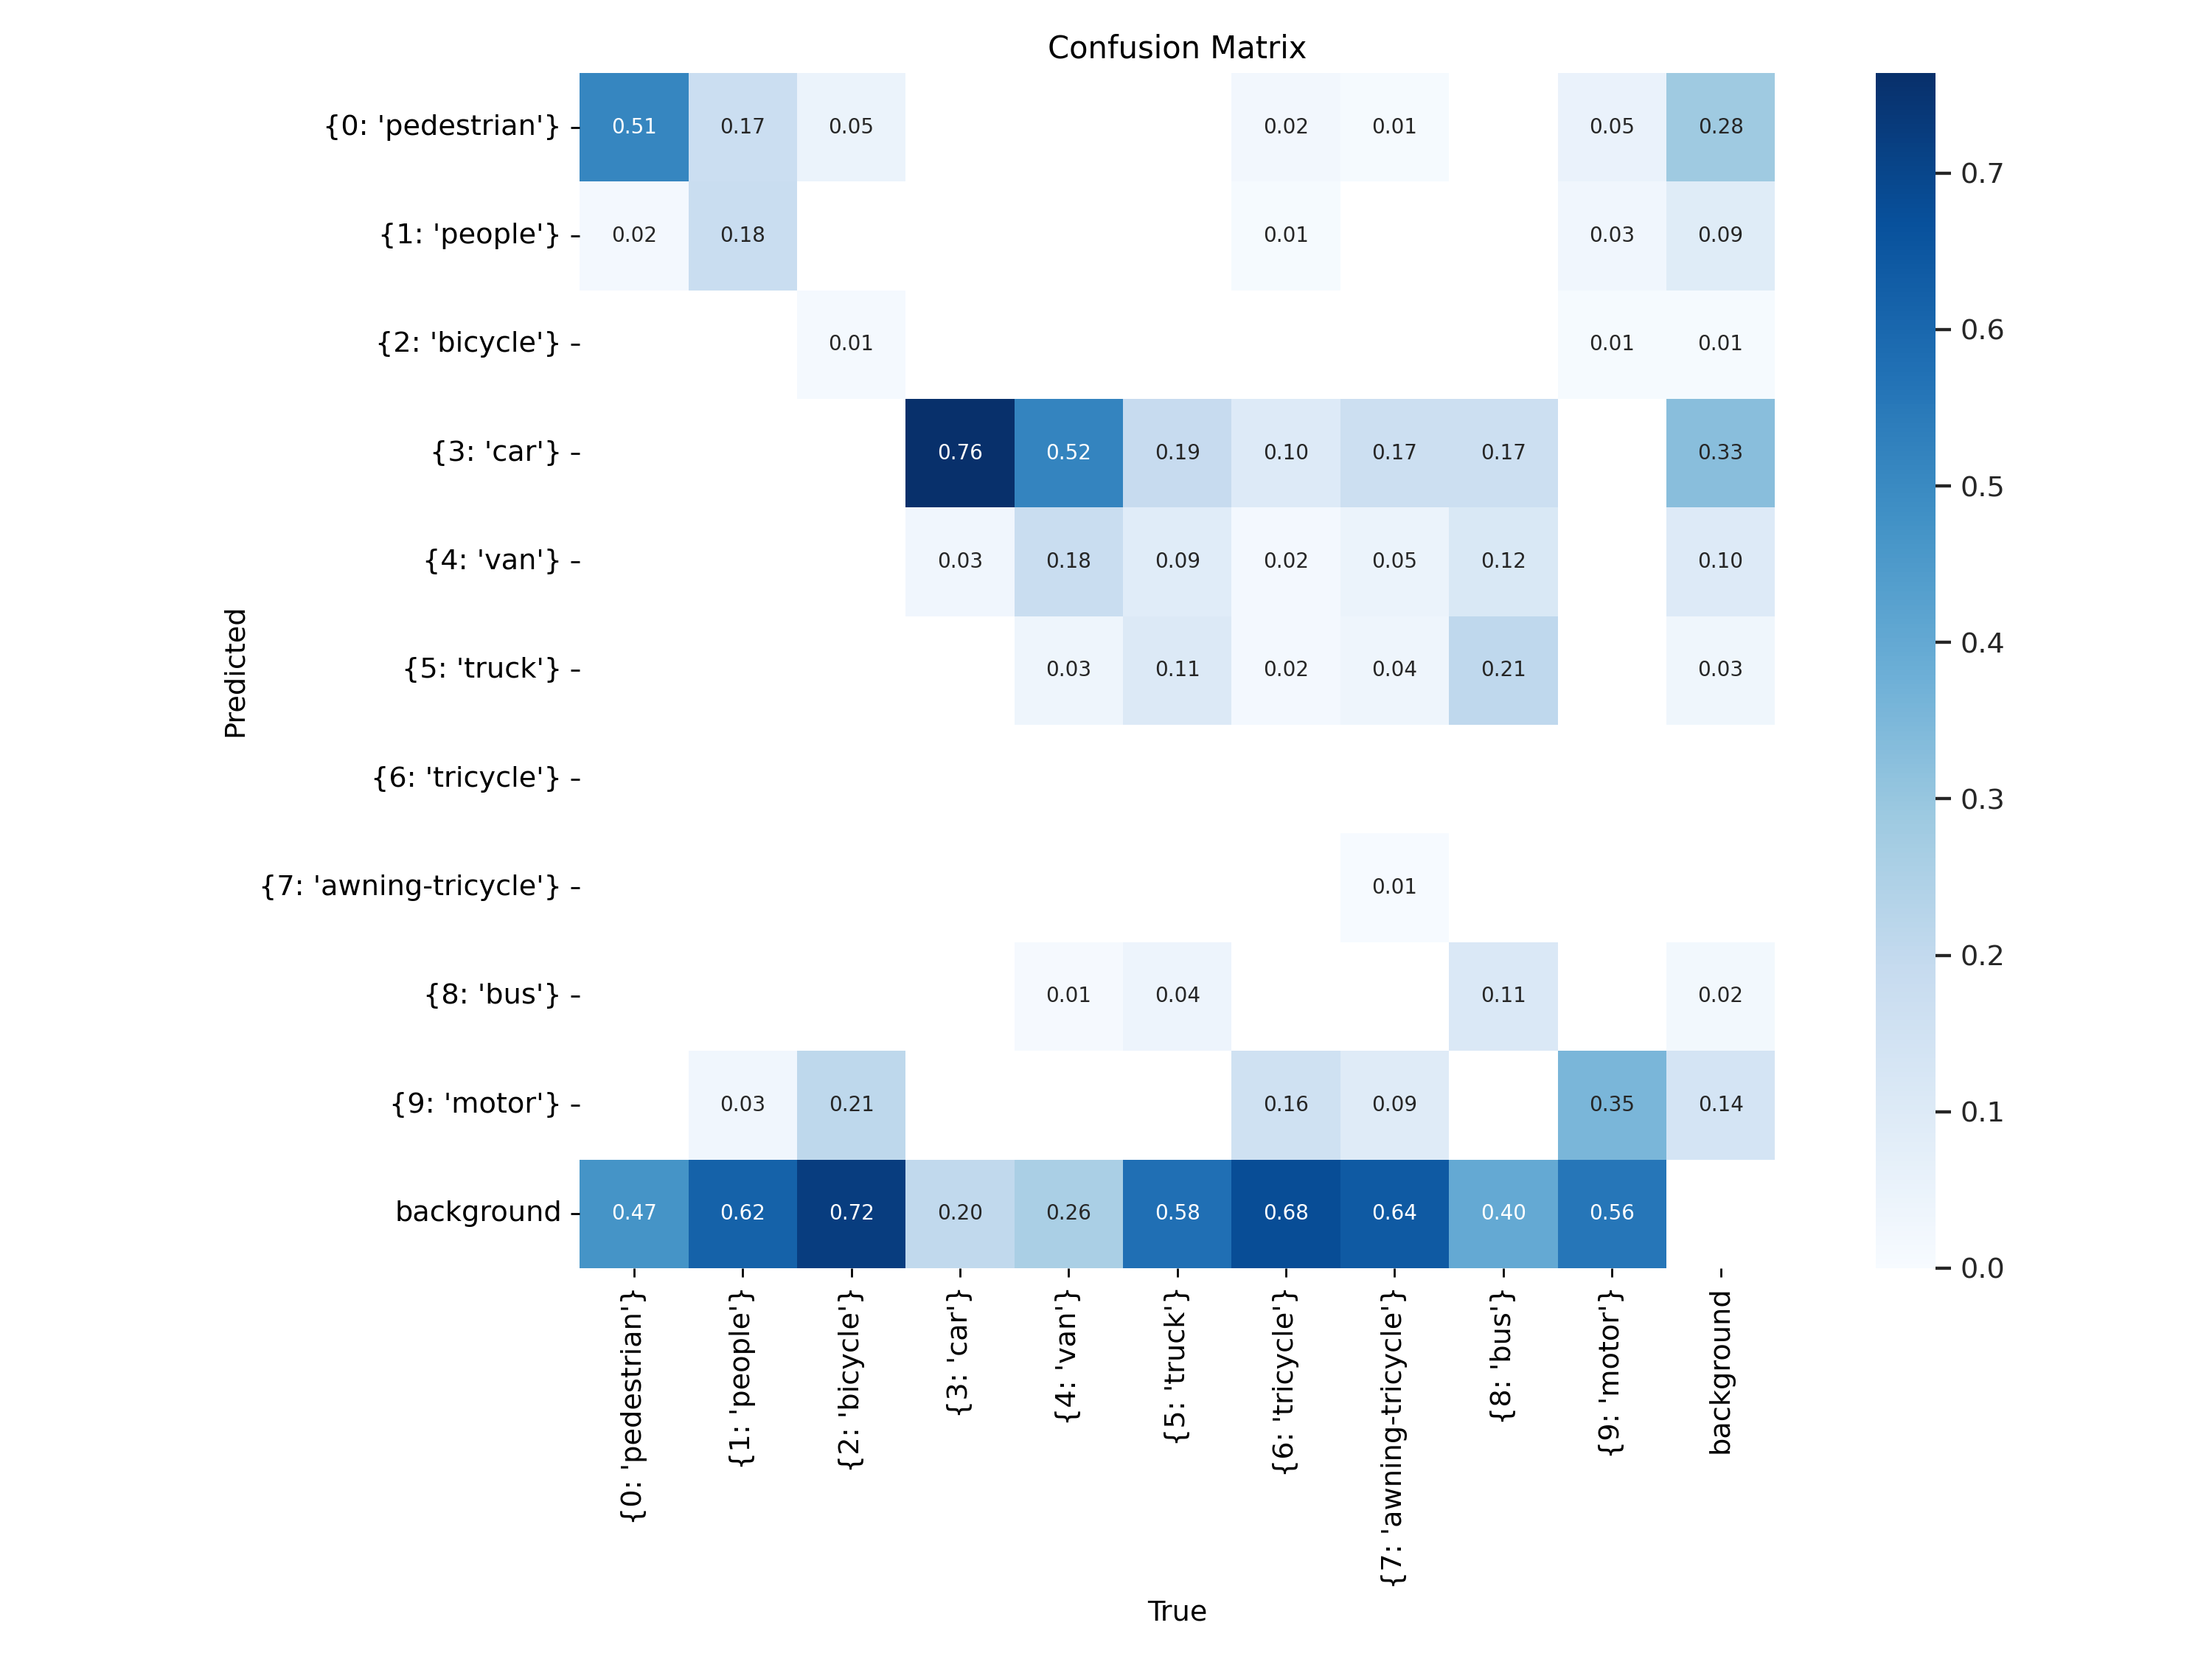

In [ ]:
from IPython.display import Image, display

display(Image("runs/val/exp3/confusion_matrix.png"))

In [ ]:
display(Image("runs/val/exp3/confusion_matrix.png"))
R_curve.png	     val_batch1_pred.jpg
F1_curve.png	      val_batch0_labels.jpg  val_batch2_labels.jpg
P_curve.png	      val_batch0_pred.jpg    val_batch2_pred.jpg
PR_curve.png	      val_batch1_labels.jpg

In [ ]:
from models.common import DetectMultiBackend

model = DetectMultiBackend(
    "runs/train/exp2/weights/best.pt"
)

model.eval()

Fusing layers... 
Model summary: 267 layers, 46156743 parameters, 0 gradients, 107.8 GFLOPs


DetectMultiBackend(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 64, kernel_size=(6, 6), stride=(2, 2), padding=(2, 2))
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (act): SiLU(inplace=True)
      )
      (2): C3(
        (cv1): Conv(
          (conv): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1))
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1))
          (act): SiLU(inplace=True)
        )
        (cv3): Conv(
          (conv): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
          (act): SiLU(inplace=True)
        )
        (m): Sequential(
          (0): Bottleneck(
            (cv1): Conv(
              (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
              (act): SiLU(inplace=True)
            )
            (cv2): 

In [ ]:
for i, layer in enumerate(model.model.model):
    print(i, layer)

0 Conv(
  (conv): Conv2d(3, 64, kernel_size=(6, 6), stride=(2, 2), padding=(2, 2))
  (act): SiLU(inplace=True)
)
1 Conv(
  (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (act): SiLU(inplace=True)
)
2 C3(
  (cv1): Conv(
    (conv): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1))
    (act): SiLU(inplace=True)
  )
  (cv2): Conv(
    (conv): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1))
    (act): SiLU(inplace=True)
  )
  (cv3): Conv(
    (conv): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
    (act): SiLU(inplace=True)
  )
  (m): Sequential(
    (0): Bottleneck(
      (cv1): Conv(
        (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (act): SiLU(inplace=True)
      )
    )
    (1): Bottleneck(
      (cv1): Conv(
        (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
       

In [ ]:
target_layers = [model.model.model[-2]]

In [ ]:
for i in range(len(model.model.model)-5, len(model.model.model)):
    print(i, model.model.model[i])

20 C3(
  (cv1): Conv(
    (conv): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (act): SiLU(inplace=True)
  )
  (cv2): Conv(
    (conv): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (act): SiLU(inplace=True)
  )
  (cv3): Conv(
    (conv): Conv2d(512, 512, kernel_size=(1, 1), stride=(1, 1))
    (act): SiLU(inplace=True)
  )
  (m): Sequential(
    (0): Bottleneck(
      (cv1): Conv(
        (conv): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (act): SiLU(inplace=True)
      )
    )
    (1): Bottleneck(
      (cv1): Conv(
        (conv): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (act): SiLU(inplace=True)
      )
    )
    (2): Bottleneck(
      (cv1):

In [ ]:
#last layer before object representation
target_layers = [model.model.model[23]]

In [ ]:
!ls /content/datasets/VisDrone/images/test

0000006_00159_d_0000001.jpg  9999944_00000_d_0000003.jpg
0000006_00611_d_0000002.jpg  9999944_00000_d_0000004.jpg
0000006_01111_d_0000003.jpg  9999947_00000_d_0000001.jpg
0000006_01275_d_0000004.jpg  9999947_00000_d_0000002.jpg
0000006_01659_d_0000004.jpg  9999947_00000_d_0000003.jpg
0000006_02138_d_0000006.jpg  9999947_00000_d_0000004.jpg
0000006_02616_d_0000007.jpg  9999947_00000_d_0000005.jpg
0000006_03636_d_0000009.jpg  9999947_00000_d_0000006.jpg
0000006_04050_d_0000010.jpg  9999947_00000_d_0000007.jpg
0000006_04309_d_0000011.jpg  9999947_00000_d_0000008.jpg
0000006_05168_d_0000013.jpg  9999947_00000_d_0000009.jpg
0000006_05208_d_0000014.jpg  9999947_00000_d_0000010.jpg
0000006_05575_d_0000016.jpg  9999947_00000_d_0000011.jpg
0000006_05999_d_0000017.jpg  9999947_00000_d_0000012.jpg
0000006_06773_d_0000018.jpg  9999947_00000_d_0000013.jpg
0000006_07596_d_0000020.jpg  9999947_00000_d_0000014.jpg
0000011_00234_d_0000001.jpg  9999947_00000_d_0000015.jpg
0000011_01350_d_0000003.jpg  99

In [ ]:
!pwd

/content/yolov5


In [ ]:
%cd /content/

/content


In [ ]:
#!git clone https://github.com/pooya-mohammadi/yolov5-gradcam.git
#%cd yolov5-gradcam
#!pip install -r requirements.txt

In [ ]:
#!python main.py \
#    --model-path /content/yolov5/runs/train/exp2/weights/best.pt \
#    --img-path /content/datasets/VisDrone/images/test/9999938_00000_d_0000506.jpg \
#    --output-dir outputs

In [ ]:
!cat requirements.txt

# pip install -r requirements.txt

# Base ----------------------------------------
matplotlib>=3.2.2
numpy>=1.18.5
opencv-python>=4.5.4
Pillow>=7.1.2
PyYAML>=5.3.1
requests>=2.23.0
scipy>=1.4.1
torch>=1.7.0,<1.11.0
torchvision>=0.8.1
tqdm>=4.41.0
# Logging -------------------------------------
tensorboard>=2.4.1
# wandb

# Plotting ------------------------------------
pandas>=1.1.4
seaborn>=0.11.0

# loading model ---------------------------------------
deep_utils>=0.8.5


In [ ]:
device = torch.device('cuda')

model = model.to(device)
input_tensor = input_tensor.to(device)

with torch.no_grad():
    outputs = model(input_tensor)

In [ ]:
with torch.no_grad():
    outputs = model(input_tensor.cuda())

print(type(outputs))

if isinstance(outputs, (tuple, list)):
    print("length =", len(outputs))
    for i, x in enumerate(outputs):
        print(i, type(x))
        if hasattr(x, "shape"):
            print(x.shape)

<class 'list'>
length = 2
0 <class 'torch.Tensor'>
torch.Size([1, 25200, 15])
1 <class 'list'>


In [ ]:
import torch
import torch.nn as nn

class YOLOScoreTarget(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):

        pred = self.model(x)[0]

        # objectness score
        obj = pred[..., 4]

        # strongest detection
        return obj.max().unsqueeze(0)

In [ ]:
device = torch.device("cuda")

model = model.to(device)
model.eval()

cam_model = YOLOScoreTarget(model).to(device)

In [ ]:
target_layers = [model.model.model[23]]

In [ ]:
from utils.augmentations import letterbox
import cv2
import numpy as np

img = cv2.imread("/content/datasets/VisDrone/images/test/9999938_00000_d_0000506.jpg")

img = letterbox(
    img,
    new_shape=640,
    stride=32,
    auto=False
)[0]

rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

rgb_float = rgb.astype(np.float32) / 255.0

input_tensor = (
    torch.from_numpy(rgb_float)
    .permute(2,0,1)
    .unsqueeze(0)
    .float()
    .to(device)
)

In [ ]:
from pytorch_grad_cam import EigenCAM

cam = EigenCAM(
    model=cam_model,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor
)[0]

TypeError: 'numpy.int64' object is not iterable

In [ ]:
with torch.no_grad():
    out = cam_model(input_tensor)

print(type(out))
print(out)
print(out.shape if hasattr(out, "shape") else "no shape")

<class 'torch.Tensor'>
tensor([0.81802], device='cuda:0')
torch.Size([1])


In [ ]:
import torch.nn as nn

class YOLOScoreTarget(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        pred = self.model(x)[0]

        # objectness scores
        obj = pred[..., 4]

        score = obj.max()

        # CAM expects [batch, classes]
        return score.view(1, 1)

In [ ]:
cam_model = YOLOScoreTarget(model).to(device)

In [ ]:
with torch.no_grad():
    out = cam_model(input_tensor)

print(out.shape)

torch.Size([1, 1])


In [ ]:
from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

cam = EigenCAM(
    model=cam_model,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=[ClassifierOutputTarget(0)]
)[0]

In [ ]:
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt

visualization = show_cam_on_image(
    rgb_float,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(10,10))
plt.imshow(visualization)
plt.axis("off")
plt.show()

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

cam = GradCAM(
    model=cam_model,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=[ClassifierOutputTarget(0)]
)[0]

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

In [ ]:
pred = model(input_tensor)[0]

print(pred.requires_grad)
print(pred[...,4].max().requires_grad)

False
False


In [ ]:
from IPython.display import Image, display

display(Image("outputs/result.jpg"))

TPH-YOLOv5: Improved YOLOv5 Based on Transformer Prediction Head for Object Detection on Drone-captured Scenarios
https://arxiv.org/pdf/2108.11539



https://github.com/cv516Buaa/tph-yolov5

https://github.com/VisDrone/VisDrone-Dataset

1. Dataset: VisDrone2021
2. Goal: Object detection on drone-captured scenarios
3. Improvements from YOLOv5:
* We replace the original prediction heads with Transformer Prediction Heads (TPH) to explore the prediction potential with self-attention mechanism.
* We integrate convolutional block attention model (CBAM) to find attention region on scenarios with dense objects.
* Strategies such as data augmentation, multiscale testing, multi-model integration and utilizing extra classifier.


* VisDrone2021-DET dataset is the same as VisDrone2019-DET dataset.

In [ ]:
! git clone https://github.com/cv516Buaa/tph-yolov5.git

Cloning into 'tph-yolov5'...
remote: Enumerating objects: 246, done.
remote: Counting objects: 100% (246/246), done.
remote: Compressing objects: 100% (145/145), done.
remote: Total 246 (delta 106), reused 218 (delta 97), pack-reused 0 (from 0)
Receiving objects: 100% (246/246), 9.27 MiB | 14.25 MiB/s, done.
Resolving deltas: 100% (106/106), done.


In [ ]:
%cd tph-yolov5
! pip install -r requirements.txt

/content/tph-yolov5


In [ ]:
%cd data

/content/tph-yolov5/data


In [ ]:
!ls

Argoverse.yaml	      hyps	       SKU-110K.yaml  xView.yaml
coco128.yaml	      images	       UAVDT.yaml
coco.yaml	      Objects365.yaml  VisDrone.yaml
GlobalWheat2020.yaml  scripts	       VOC.yaml


In [ ]:
%cd ..

/content/tph-yolov5


In [ ]:
!ls

CONTRIBUTING.md  hubconf.py  requirements.txt  tutorial.ipynb
data		 images      result.png        utils
detect.py	 LICENSE     setup.cfg	       val.py
Dockerfile	 models      train.png	       VisDrone2YOLO_lable.py
export.py	 README.md   train.py	       wbf.py


In [ ]:
!pwd
!ls -R

/content/tph-yolov5
.:
CONTRIBUTING.md  hubconf.py  requirements.txt  tutorial.ipynb
data		 images      result.png        utils
detect.py	 LICENSE     setup.cfg	       val.py
Dockerfile	 models      train.png	       VisDrone2YOLO_lable.py
export.py	 README.md   train.py	       wbf.py

./data:
Argoverse.yaml	      hyps	       SKU-110K.yaml  xView.yaml
coco128.yaml	      images	       UAVDT.yaml
coco.yaml	      Objects365.yaml  VisDrone.yaml
GlobalWheat2020.yaml  scripts	       VOC.yaml

./data/hyps:
hyp.finetune_objects365.yaml  hyp.scratch-low.yaml  hyp.UAVDT.yaml
hyp.finetune.yaml	      hyp.scratch-med.yaml  hyp.VisDrone.yaml
hyp.scratch-high.yaml	      hyp.scratch.yaml

./data/images:
bus.jpg  zidane.jpg

./data/scripts:
download_weights.sh  get_coco128.sh  get_coco.sh

./images:
README.md  result_in_UAVDT.png	result_in_VisDrone.png

./models:
common.py	 yolo.py			    yolov5m.yaml
experimental.py  yolov5l-tph-plus.yaml		    yolov5n.yaml
hub		 yolov5l-xs-tph.yaml		    yolov5s.yaml
__i

In [ ]:
%cd ..

/content


In [ ]:
%cd /content/tph-yolov5/

/content/tph-yolov5


In [ ]:
!python VisDrone2YOLO_lable.py

548


* The weights' files they provided don't work, so I gonna use yolov5x weights

In [ ]:
%cd ..

/content


In [ ]:
%mkdir weights

In [ ]:
%cd weights

/content/weights


In [ ]:
!wget https://github.com/ultralytics/yolov5/releases/download/v6.1/yolov5l.pt

In [ ]:
!wget https://github.com/ultralytics/yolov5/releases/download/v6.1/yolov5x.pt

--2026-06-08 01:33:24--  https://github.com/ultralytics/yolov5/releases/download/v6.1/yolov5x.pt
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/264818686/a7014a41-f517-4ef0-ad4e-6ccab3ad2a94?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-06-08T02%3A09%3A32Z&rscd=attachment%3B+filename%3Dyolov5x.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-06-08T01%3A09%3A12Z&ske=2026-06-08T02%3A09%3A32Z&sks=b&skv=2018-11-09&sig=FaZlCJzJNrw3YC%2FznNZKSkNw2pOBhxubsk5LAZLqtCw%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4MDg4NjAwNCwibmJmIjoxNzgwODgyNDA0LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNvc

In [ ]:
!ls

yolov5l.pt  yolov5x.pt


In [ ]:
%cd ..

/content


In [ ]:
#!python val.py --weights ./weights/yolov5l-xs-1.pt --img 1996 --data ./data/VisDrone.yaml
#                                    yolov5l-xs-2.pt
#--augment --save-txt  --save-conf --task val --batch-size 8 --verbose --name v5l-xs

In [ ]:
from pathlib import Path

p = Path("/content/tph-yolov5/models/experimental.py")
txt = p.read_text()

txt = txt.replace(
    "ckpt = torch.load(attempt_download(w), map_location=map_location)",
    "ckpt = torch.load(attempt_download(w), map_location=map_location, weights_only=False)"
)

p.write_text(txt)
print("patched")

patched


In [ ]:
from pathlib import Path

p = Path("/content/tph-yolov5/utils/datasets.py")
txt = p.read_text()

txt = txt.replace("np.int)", "int)")
txt = txt.replace("np.int,", "int,")

p.write_text(txt)

print("patched")

patched


In [ ]:
from pathlib import Path

p = Path("/content/tph-yolov5/train.py")
txt = p.read_text()

txt = txt.replace(
    "ckpt = torch.load(weights, map_location=device)",
    "ckpt = torch.load(weights, map_location=device, weights_only=False)"
)

p.write_text(txt)
print("patched train.py")

patched train.py


In [ ]:
!grep -R "torch.load(" -n /content/tph-yolov5

/content/tph-yolov5/hubconf.py:51:                ckpt = torch.load(attempt_download(path), map_location=device)  # load
/content/tph-yolov5/models/experimental.py:96:        ckpt = torch.load(attempt_download(w), map_location=map_location, weights_only=False)  # load
/content/tph-yolov5/train.py:118:        ckpt = torch.load(weights, map_location=device, weights_only=False)  # load checkpoint
/content/tph-yolov5/utils/aws/resume.py:19:    ckpt = torch.load(last)
/content/tph-yolov5/utils/general.py:729:    x = torch.load(f, map_location=torch.device('cpu'))
/content/tph-yolov5/utils/loggers/__init__.py:67:            run_id = torch.load(self.weights).get('wandb_id') if self.opt.resume and not wandb_artifact_resume else None
/content/tph-yolov5/detect.py:92:            modelc.load_state_dict(torch.load('resnet50.pt', map_location=device)['model']).to(device).eval()


In [ ]:
from pathlib import Path

for p in Path("/content/tph-yolov5").rglob("*.py"):
    txt = p.read_text()
    txt = txt.replace("np.int", "int")
    txt = txt.replace("np.float", "float")
    txt = txt.replace("np.bool", "bool")
    txt = txt.replace("float64", "np.float64")
    txt = txt.replace("float16", "np.float16")
    txt = txt.replace("float32", "np.float32")
    txt = txt.replace("int16", "np.int16")
    txt = txt.replace("int32", "np.int32")
    txt = txt.replace("int64", "np.int64")
    p.write_text(txt)

print("Patched deprecated NumPy aliases.")

Patched deprecated NumPy aliases.


All this was to solve compatibility issues

In [ ]:
import os

max_cls = -1

for root, _, files in os.walk("/path/to/labels"):
    for f in files:
        if f.endswith(".txt"):
            with open(os.path.join(root, f)) as fp:
                for line in fp:
                    if line.strip():
                        cls = int(float(line.split()[0]))
                        max_cls = max(max_cls, cls)

print("Maximum class id:", max_cls)

Maximum class id: -1


VisDrone2YOLO_lable.py mapped the labels wrong

In [ ]:
!pwd

/content


In [ ]:
%cd tph-yolov5/

/content/tph-yolov5


In [ ]:
#!python train.py --img 1536 --adam --batch 4 --epochs 80 --data ./data/VisDrone.yaml --weights yolov5l.pt --hy data/hyps/hyp.VisDrone.yaml --cfg models/yolov5l-xs-tph.yaml --name v5l-xs-tph
#!python train.py --img 1536 --adam --batch 4 --epochs 80 --data ./data/VisDrone.yaml --weights yolov5l.pt --hy data/hyps/hyp.VisDrone.yaml --cfg models/yolov5l-tph-plus.yaml --name v5l-tph-plus

2026-06-08 02:14:09.706627: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: WARNING W&B disabled due to login timeout.
wandb: ERROR Error while calling W&B API: api key too short (<Response [401]>)
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train: weights=yolov5l.pt, cfg=models/yolov5l-xs-tph.yaml, data=./data/VisDrone.yaml, hyp=data/hyps/hyp.VisDrone.yaml, epochs=80, batch_size=4, imgsz=1536, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, evolve=None, bucket=, cache=None, image_weights=False, device=, multi_scale=False, sing

In [ ]:
!python train.py \
  --weights weights/yolov5x.pt \
  --cfg models/yolov5l-xs-tph.yaml \
  --data yolov5/data/visdrone.yaml \
  --img 1536 \
  --batch-size 2 \
  --epochs 65 \
  --name visdrone_tph

2026-06-08 01:48:52.913948: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 3
wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train: weights=weights/yolov5l.pt, cfg=models/yolov5l-xs-tph.yaml, data=data/VisDrone.yaml, hyp=data/hyps/hyp.scratch.yaml, epochs=65, batch_size=2, imgsz=1536, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, evolve=None, bucket=, cache=None, image_weights=False, device=, multi_scale=False, single_cls=False, adam=False, sync_bn=False, wo

In [ ]:
!python val.py --weights ./weights/yolov5x.pt --img 1996 --data .yolov5/data/visdrone.yaml --augment --save-txt  --save-conf --task val --batch-size 4 --verbose --name v5l-xs

val: data=./data/VisDrone.yaml, weights=['./weights/yolov5l.pt'], batch_size=4, imgsz=1996, conf_thres=0.001, iou_thres=0.6, task=val, device=, single_cls=False, augment=True, verbose=True, save_txt=True, save_hybrid=False, save_conf=True, save_json=False, project=runs/val, name=v5l-xs, exist_ok=False, half=False
YOLOv5 🚀 052dfeb torch 2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model Summary: 367 layers, 46533693 parameters, 0 gradients, 109.0 GFLOPs
val: Scanning '../datasets/VisDrone/VisDrone2019-DET-val/labels.cache' images and labels... 548 found, 0 missing, 0 empty, 0 corrupted: 100% 548/548 [00:00<?, ?it/s]
               Class     Images     Labels          P          R     mAP@.5 mAP@.5:.95:   0% 0/137 [00:03<?, ?it/s]
Traceback (most recent call last):
  File "/content/tph-yolov5/val.py", line 359, in <module>
    main(opt)
  File "/content/tph-yolov5/val.py", line 333, in main
    run(**vars(opt))
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/_c

In [ ]:
!python wbf.py

Traceback (most recent call last):
  File "/content/tph-yolov5/wbf.py", line 40, in <module>
    image_ids = os.listdir(IMG_PATH)
                ^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/VisDrone2019-DET-test-challenge/images/'


In [ ]:
!python val.py --weights ./weights/yolov5l.pt --img 1996 --data ./data/VisDrone.yaml --augment --save-txt  --save-conf --task val --batch-size 8 --verbose --name v5l

val: data=./data/VisDrone.yaml, weights=['./weights/yolov5l.pt'], batch_size=8, imgsz=1996, conf_thres=0.001, iou_thres=0.6, task=val, device=, single_cls=False, augment=True, verbose=True, save_txt=True, save_hybrid=False, save_conf=True, save_json=False, project=runs/val, name=v5l, exist_ok=False, half=False
YOLOv5 🚀 052dfeb torch 2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model Summary: 367 layers, 46533693 parameters, 0 gradients, 109.0 GFLOPs
val: Scanning '../datasets/VisDrone/VisDrone2019-DET-val/labels.cache' images and labels... 548 found, 0 missing, 0 empty, 0 corrupted: 100% 548/548 [00:00<?, ?it/s]
Traceback (most recent call last):
  File "/content/tph-yolov5/val.py", line 359, in <module>
    main(opt)
  File "/content/tph-yolov5/val.py", line 333, in main
    run(**vars(opt))
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/_contextlib.py", line 124, in decorate_context
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "

In [ ]:
# %cd /content/tph-yolov5/utils/datasets.py

[Errno 20] Not a directory: '/content/tph-yolov5/utils/datasets.py'
/content/tph-yolov5


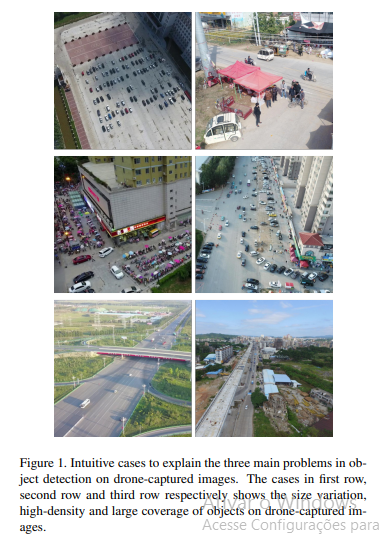

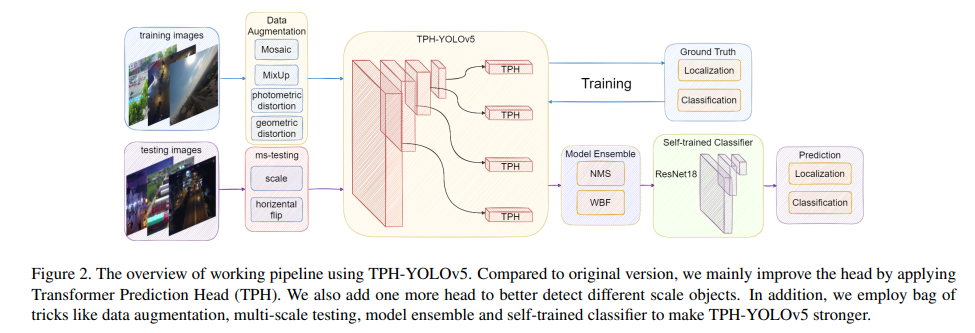

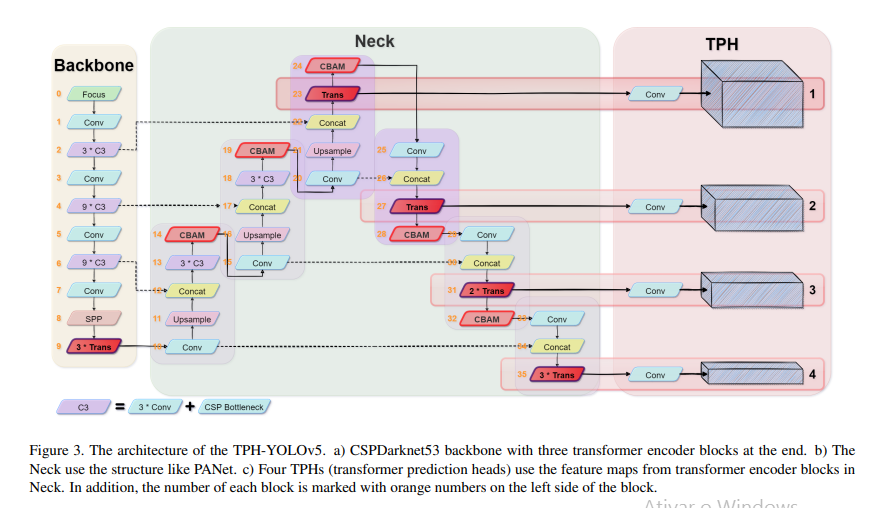

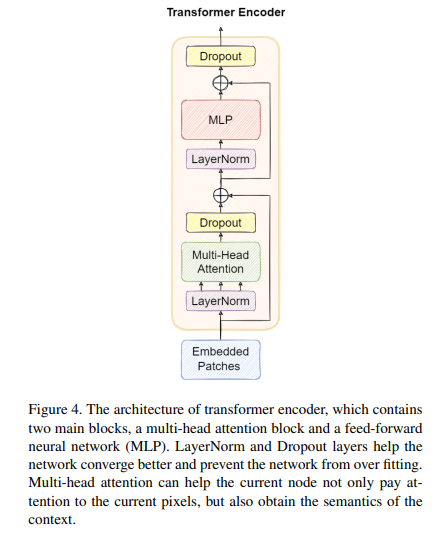

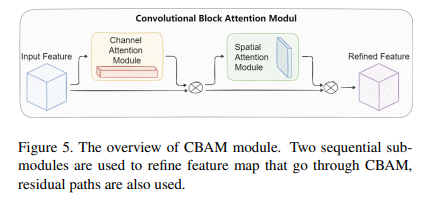

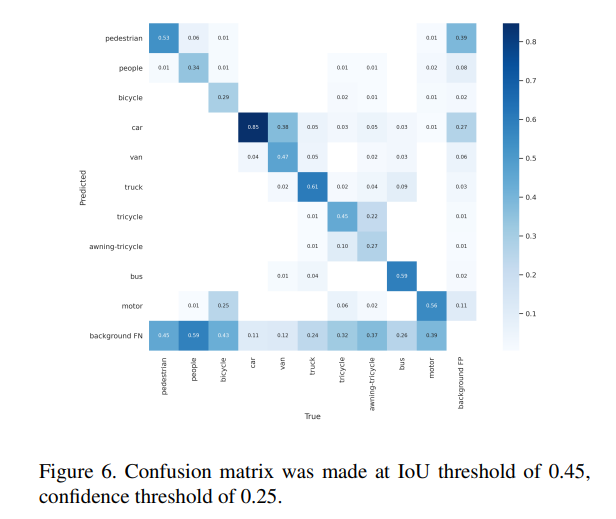

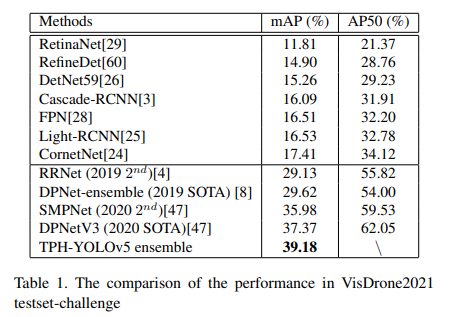

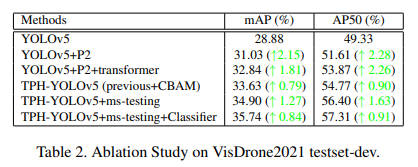

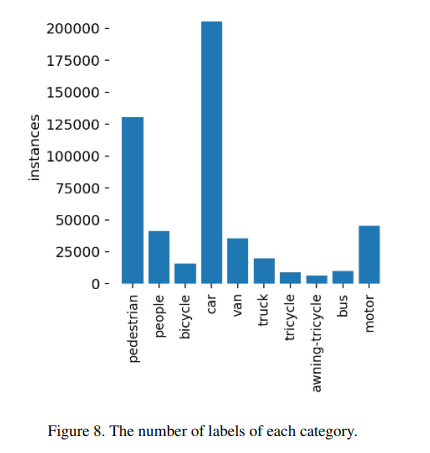

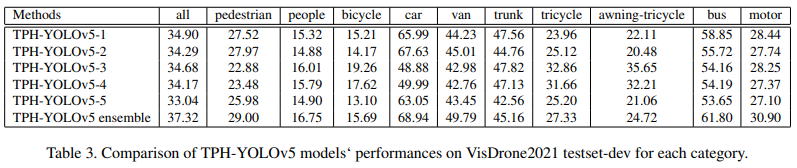

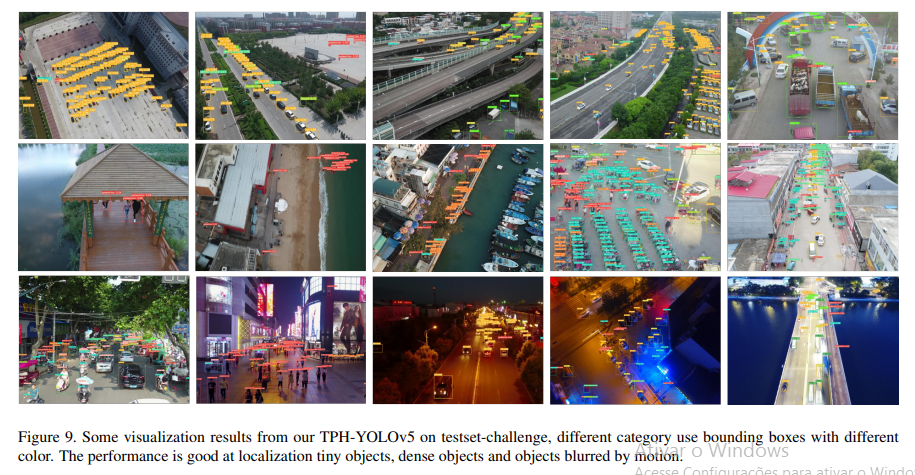